In [4]:
# repo en la branch del lab4 https://github.com/donmatthiuz/VIC/tree/lab4
import cv2
import numpy as np
import matplotlib.pyplot as plt

img1 = cv2.imread('1.png')
img2 = cv2.imread('2.png')
img3 = cv2.imread('3.png')


In [5]:
# funciones
def get_normalization_matrix(pts):
    pts = pts.reshape(-1, 2)
    mean = np.mean(pts, axis=0)
    std = np.std(pts)
    if std == 0:
        return np.eye(3)
    scale = np.sqrt(2) / std
    T = np.array([
        [scale, 0, -scale * mean[0]],
        [0, scale, -scale * mean[1]],
        [0, 0, 1]
    ])
    return T

def calcular_homografia_dlt(puntos_src, puntos_dst):
    if len(puntos_src) < 4:
        return None

    puntos_src = np.array(puntos_src)
    puntos_dst = np.array(puntos_dst)

    T_src = get_normalization_matrix(puntos_src)
    T_dst = get_normalization_matrix(puntos_dst)

    src_h = np.column_stack((puntos_src, np.ones(len(puntos_src))))
    dst_h = np.column_stack((puntos_dst, np.ones(len(puntos_dst))))

    src_norm = (T_src @ src_h.T).T
    dst_norm = (T_dst @ dst_h.T).T

    A = []
    for i in range(len(src_norm)):
        x, y = src_norm[i, 0], src_norm[i, 1]
        u, v = dst_norm[i, 0], dst_norm[i, 1]
        A.append([-x, -y, -1, 0, 0, 0, x*u, y*u, u])
        A.append([0, 0, 0, -x, -y, -1, x*v, y*v, v])

    A = np.array(A)
    U, S, Vh = np.linalg.svd(A)
    H_norm = Vh[-1].reshape(3, 3)

    H = np.linalg.inv(T_dst) @ H_norm @ T_src
    H = H / H[2, 2]
    return H

def ransac_homografia(src_pts, dst_pts, umbral, prob_exito):
    max_inliers = []
    best_H = None
    num_pts = len(src_pts)

    if num_pts < 4:
        return None, []

    iteraciones = 1000
    i = 0
    sample_size = 4

    while i < iteraciones:
        idx = np.random.choice(num_pts, sample_size, replace=False)
        src_sample = src_pts[idx]
        dst_sample = dst_pts[idx]

        H_curr = calcular_homografia_dlt(src_sample, dst_sample)
        if H_curr is None:
            i += 1
            continue

        src_h = np.column_stack((src_pts, np.ones(num_pts)))
        projected = (H_curr @ src_h.T).T

        scale_factors = projected[:, 2]
        scale_factors[scale_factors == 0] = 1e-10
        projected = projected[:, :2] / scale_factors[:, np.newaxis]

        errors = np.linalg.norm(dst_pts - projected, axis=1)
        current_inliers = np.where(errors < umbral)[0]

        if len(current_inliers) > len(max_inliers):
            max_inliers = current_inliers
            best_H = H_curr

            w = len(max_inliers) / num_pts
            if w > 0 and w < 1:
                iteraciones = int(np.log(1 - prob_exito) / np.log(1 - w**sample_size))

        i += 1

    if len(max_inliers) >= 4:
        best_H = calcular_homografia_dlt(src_pts[max_inliers], dst_pts[max_inliers])

    return best_H, max_inliers

def obtener_puntos_match(img_a, img_b):
    sift = cv2.SIFT_create()
    kp1, des1 = sift.detectAndCompute(img_a, None)
    kp2, des2 = sift.detectAndCompute(img_b, None)

    bf = cv2.BFMatcher()
    matches = bf.knnMatch(des1, des2, k=2)

    good = []
    for m, n in matches:
        if m.distance < 0.75 * n.distance:
            good.append(m)

    pts_src = np.float32([kp1[m.queryIdx].pt for m in good])
    pts_dst = np.float32([kp2[m.trainIdx].pt for m in good])

    return pts_src, pts_dst, kp1, kp2, good

def warp_images(img_src, img_dst, H):
    h1, w1 = img_src.shape[:2]
    h2, w2 = img_dst.shape[:2]

    pts_corners_src = np.float32([[0,0], [0,h1], [w1,h1], [w1,0]]).reshape(-1,1,2)
    pts_corners_dst = np.float32([[0,0], [0,h2], [w2,h2], [w2,0]]).reshape(-1,1,2)

    warped_corners = cv2.perspectiveTransform(pts_corners_src, H)
    all_corners = np.concatenate((pts_corners_dst, warped_corners), axis=0)

    [xmin, ymin] = np.int32(all_corners.min(axis=0).ravel() - 0.5)
    [xmax, ymax] = np.int32(all_corners.max(axis=0).ravel() + 0.5)

    translation_dist = [-xmin, -ymin]
    H_translation = np.array([[1, 0, translation_dist[0]], [0, 1, translation_dist[1]], [0, 0, 1]])

    output_img = cv2.warpPerspective(img_src, H_translation.dot(H), (xmax-xmin, ymax-ymin))

    h_out, w_out = output_img.shape[:2]
    y_start = translation_dist[1]
    x_start = translation_dist[0]

    output_img[y_start:y_start+h2, x_start:x_start+w2] = img_dst
    return output_img

Inliers encontrados img1->img2: 6
Inliers encontrados img3->img2: 14


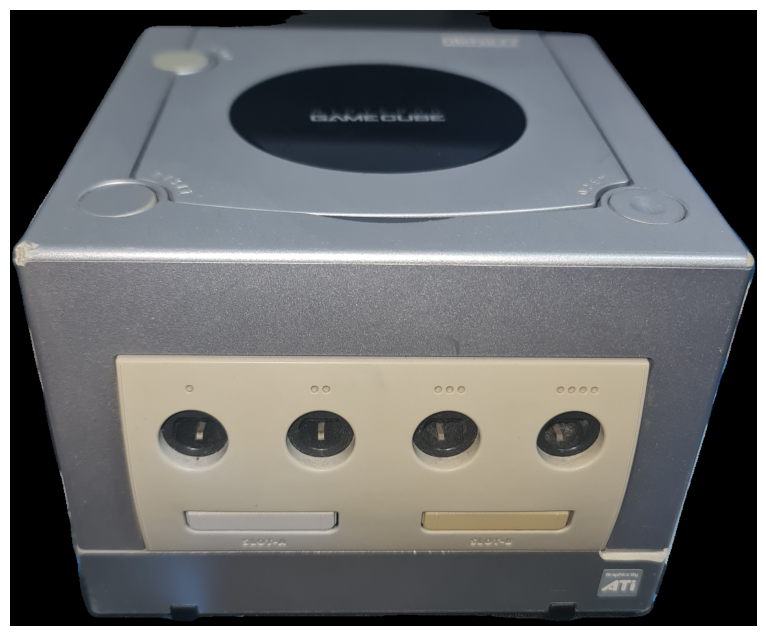

In [8]:
# mostrar resultados
pts_src_12, pts_dst_12, kp1, kp2, matches_12 = obtener_puntos_match(img1, img2)
H_12, inliers_12 = ransac_homografia(pts_src_12, pts_dst_12, umbral=4.0, prob_exito=0.99)
print(f"Inliers encontrados img1->img2: {len(inliers_12)}")

pts_src_32, pts_dst_32, kp3, _, matches_32 = obtener_puntos_match(img3, img2)
H_32, inliers_32 = ransac_homografia(pts_src_32, pts_dst_32, umbral=4.0, prob_exito=0.99)
print(f"Inliers encontrados img3->img2: {len(inliers_32)}")

panorama = img2
if H_12 is not None:
    panorama = warp_images(img1, panorama, H_12)


if H_32 is not None:
    panorama_final = warp_images(img3, panorama, H_32)
else:
    panorama_final = panorama

plt.figure(figsize=(15,8))
plt.imshow(cv2.cvtColor(panorama_final, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.show()